In [137]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [138]:
# 1. 读取图片
img = plt.imread('../data/duck.jpg')
print(img.shape)

(1080, 1080, 3)


In [139]:
# 2. 转换为张量，并改变输入数据形状
input = torch.tensor(img).permute(2, 0, 1).float() # permute()：重新排列张量的维度顺序 =》 (3, 1080, 1080)
print(input.shape)

torch.Size([3, 1080, 1080])


In [140]:
# 3. 定义卷积层
conv = nn.Conv2d(in_channels=3, out_channels=3, kernel_size=9, stride=3, padding=0, bias=False) # in_channels: 输入通道数 out_channels: 输出通道数 kernel_size: 卷积核大小 stride: 步幅 padding: 填充 bias: 是否使用偏置

In [141]:
# 4. 前向传播，得到输出
output = conv(input) # conv.forward(input)

In [142]:
# 查看输出形状
print(output.shape)

torch.Size([3, 358, 358])


In [143]:
# 5. 将输出转换为图片的形状格式
output = torch.clamp(output.int(), 0, 255) # clamp()：限制输出在0到255之间
img_output = output.permute(1, 2, 0).detach().numpy() # permute()：重新排列张量的维度顺序 =》 (358, 358, 3) detach()：从计算图中分离张量 numpy()：将张量转换为numpy数组
print(img_output.shape)

(358, 358, 3)


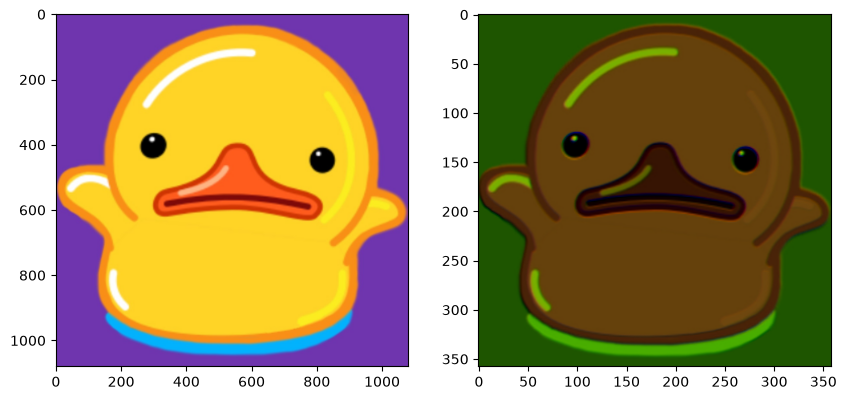

In [144]:
# 画图
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img)
ax[1].imshow(img_output)
plt.show()